In [1]:
import numpy as np
import sys
sys.path.append('..')  # Add parent directory to Python path
from notebooks.video_io import load_frames
from notebooks.utils import filter_and_label_spatiotemporal_propagation
from tqdm import tqdm
from scipy import ndimage

import matplotlib.pyplot as plt
plt.rcParams['image.origin'] = 'lower'  # Set default origin to lower
plt.rcParams['image.cmap'] = 'gray'  # Set default origin to lower

%load_ext autoreload
%autoreload 2


In [2]:
frames =  load_frames('results/20241120/test/20211026T160100Z_breaker_highlight.mp4')
frames = np.flip(frames.swapaxes(1, 2), 2)
frames = np.flip(frames, 1)
ts = frames[:, 350:850, :]
frames = frames[:, 500:1000, :]


ts = load_frames('results/20241120/test/20211026T160100Z_breakers.avi')
ts = np.flip(ts.swapaxes(1, 2), 2)
ts = np.flip(ts, 1)
print(ts.shape)
ts = ts[:, 500:1000, :]
ts.shape

0.4064gb allocated


Building Timestack: 100%|██████████| 508/508 [00:00<00:00, 783.03it/s]


0.4064gb allocated


Building Timestack: 100%|██████████| 508/508 [00:00<00:00, 948.23it/s]

(508, 1600, 500)


(508, 500, 500)

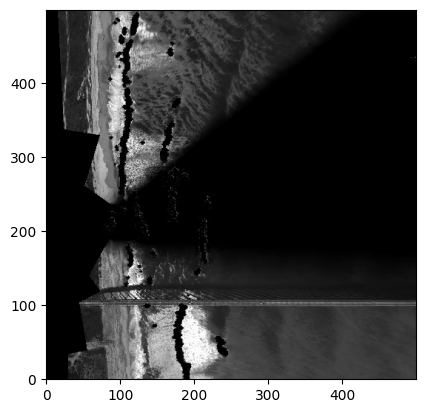

In [3]:
plt.imshow(frames[0])


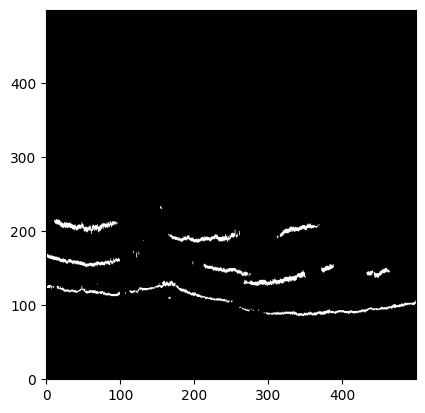

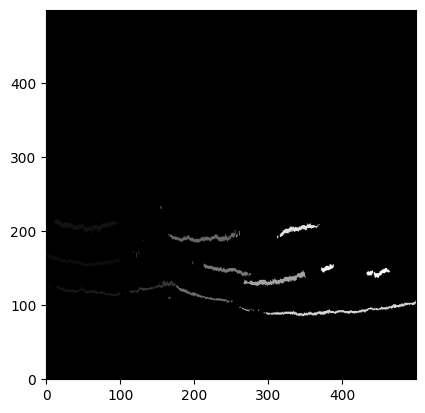

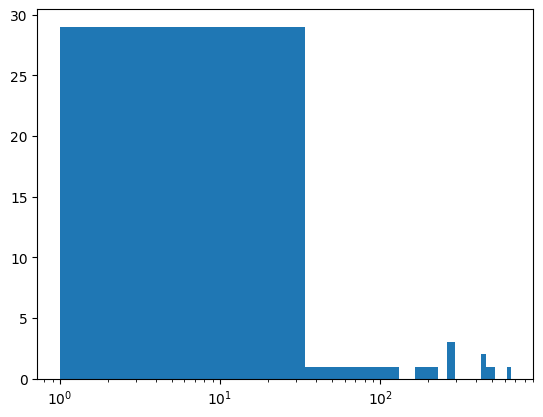

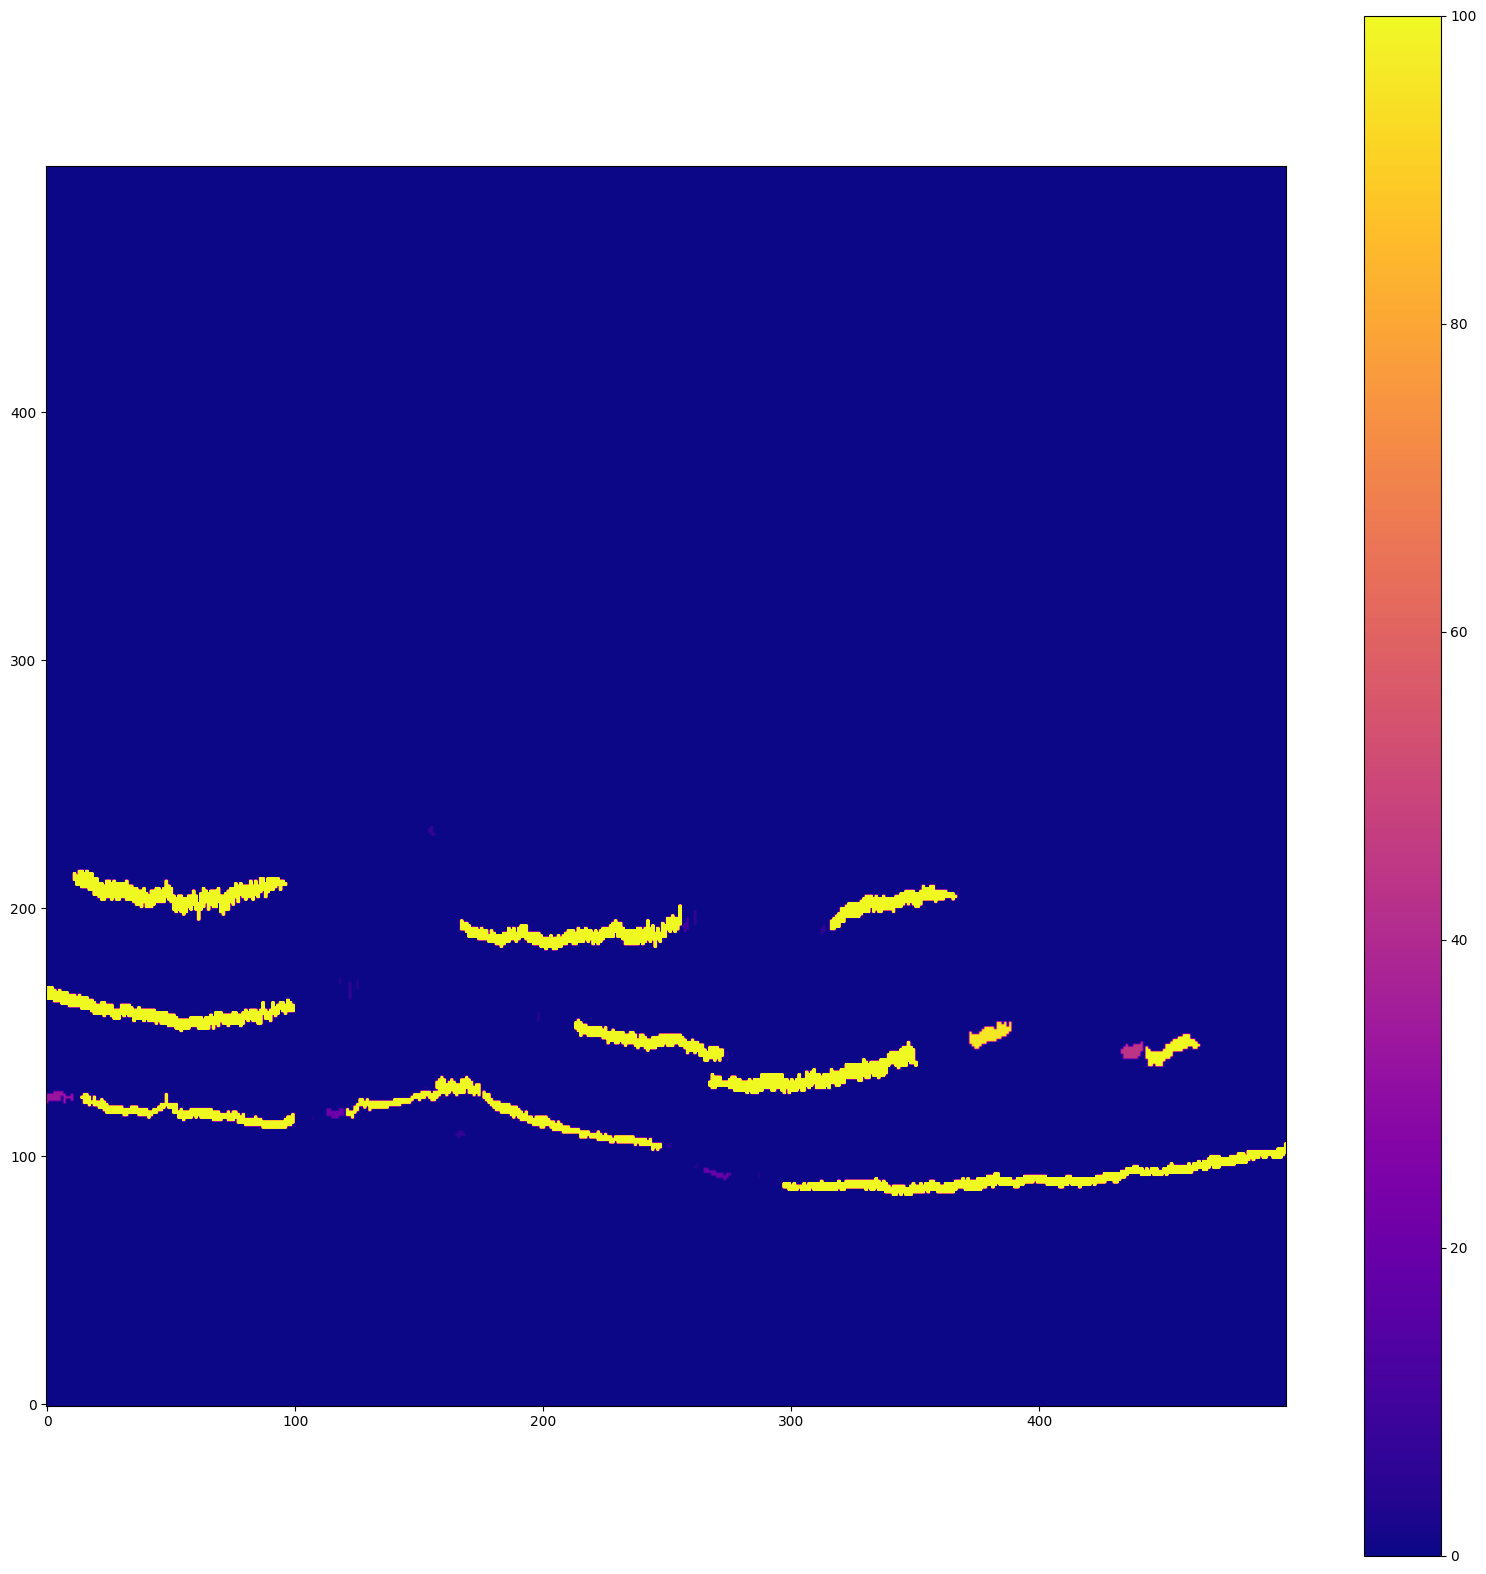

In [4]:
plt.imshow(ts[10].T)
frame = 10
labels, n_labels = ndimage.label(ts[frame])
plt.figure()
plt.imshow(labels.T)
label_nums = np.unique(labels)[1:]  # Skip 0 which is background
areas = ndimage.sum_labels(np.ones_like(labels), labels=labels, index=label_nums)
plt.figure()
plt.hist(areas, bins=20)
plt.xscale('log')


areas_im = np.zeros_like(ts[10].T)
for label in label_nums:
    areas_im[labels==label] = areas[label-1]

plt.figure(figsize=(20,20))
plt.imshow(areas_im.T, cmap='plasma', vmax=100)
plt.colorbar()

In [5]:
ts.dtype

dtype('int16')

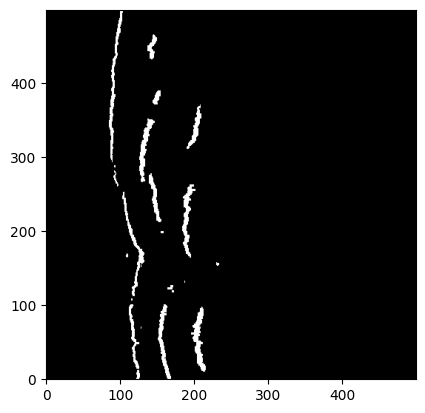

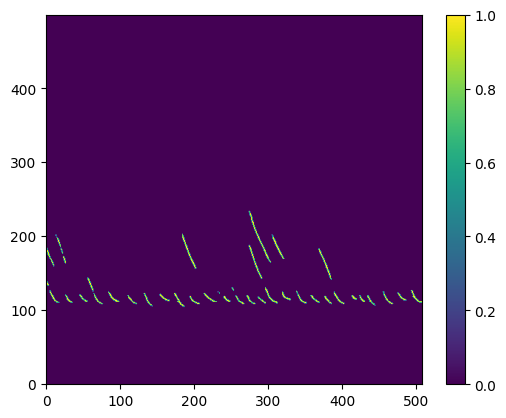

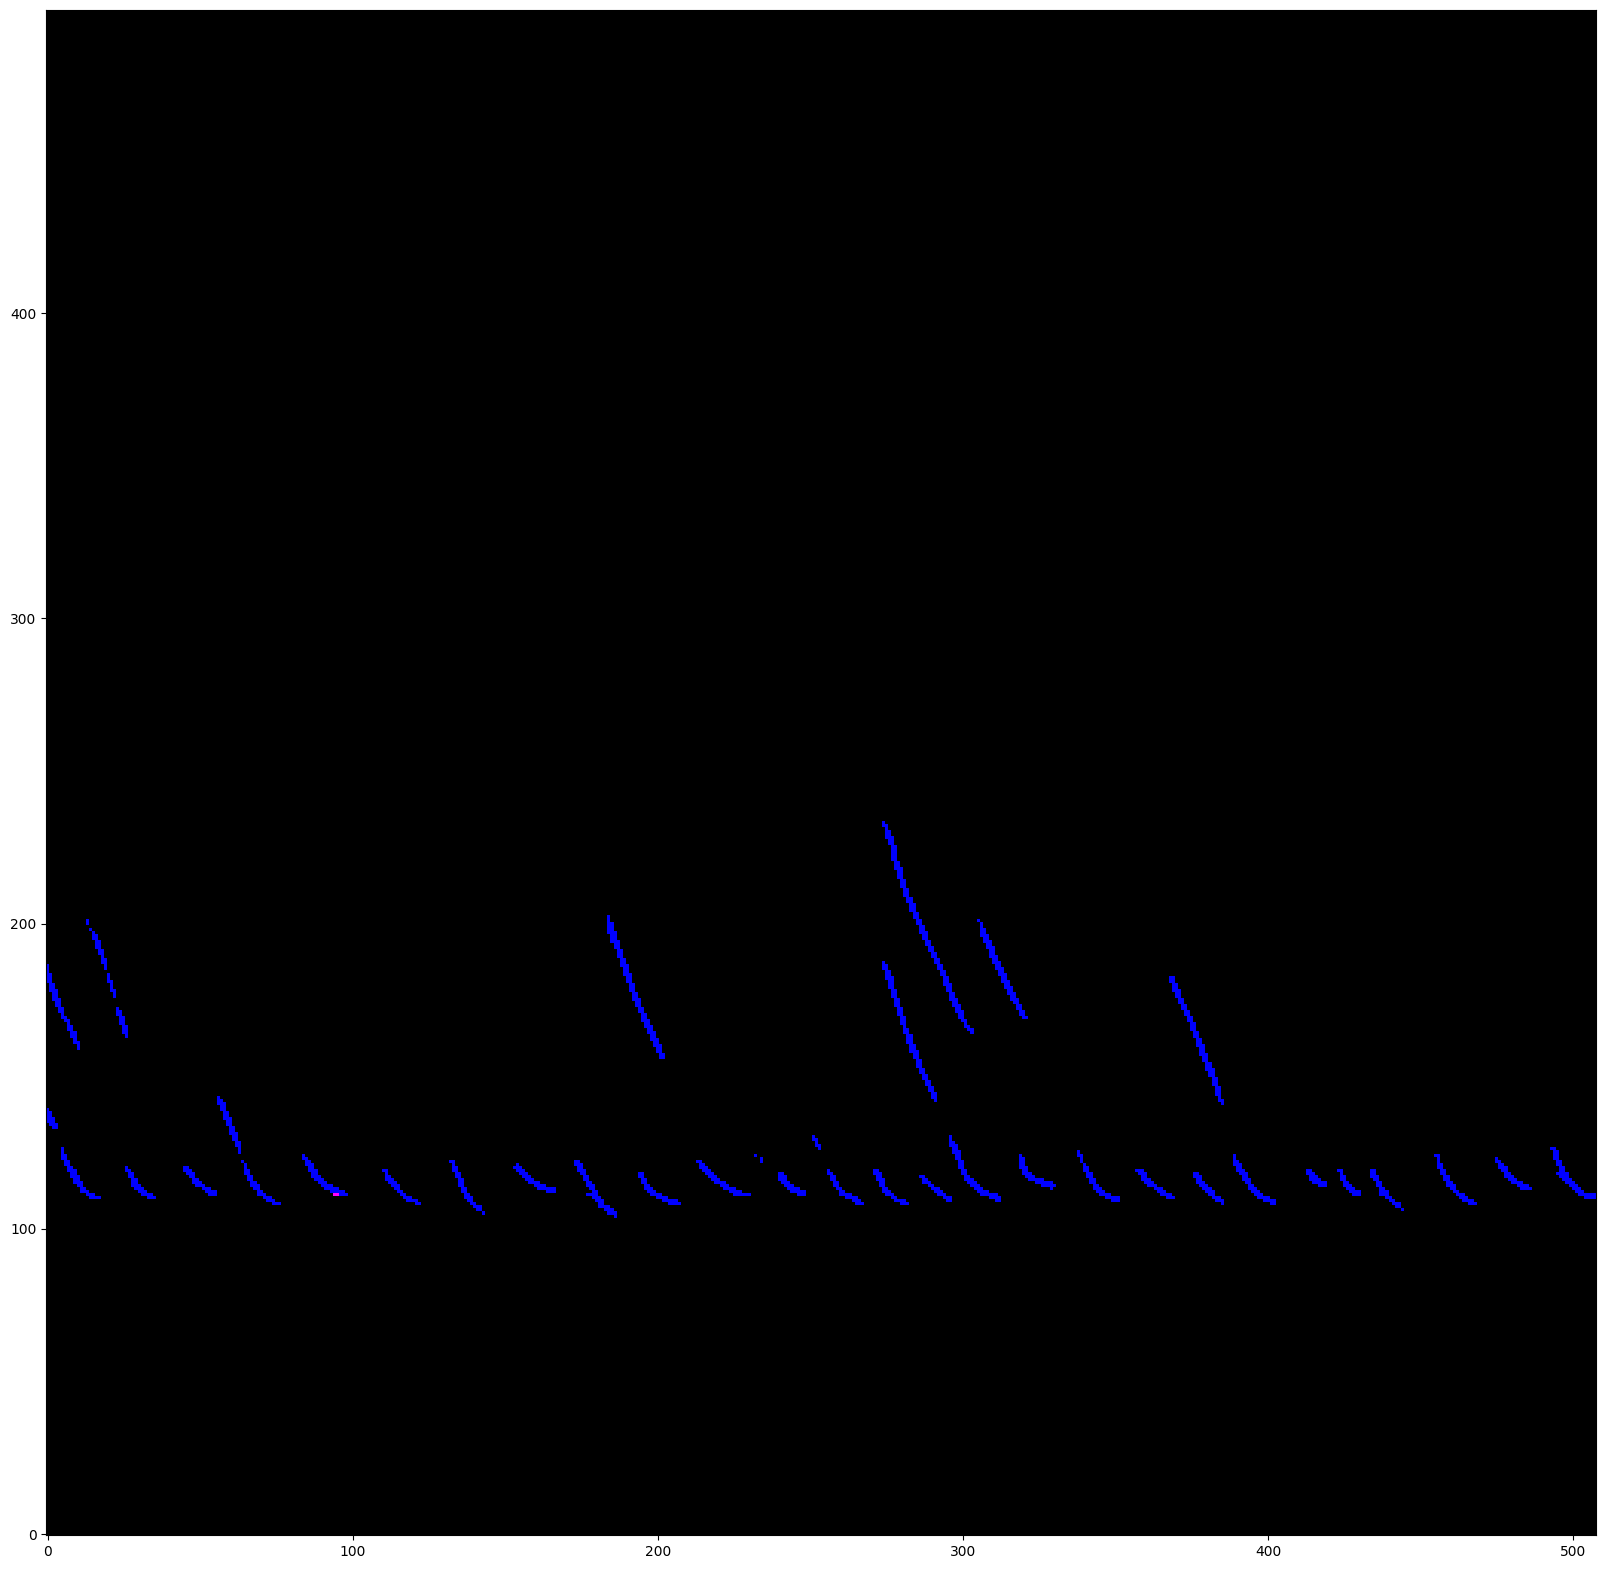

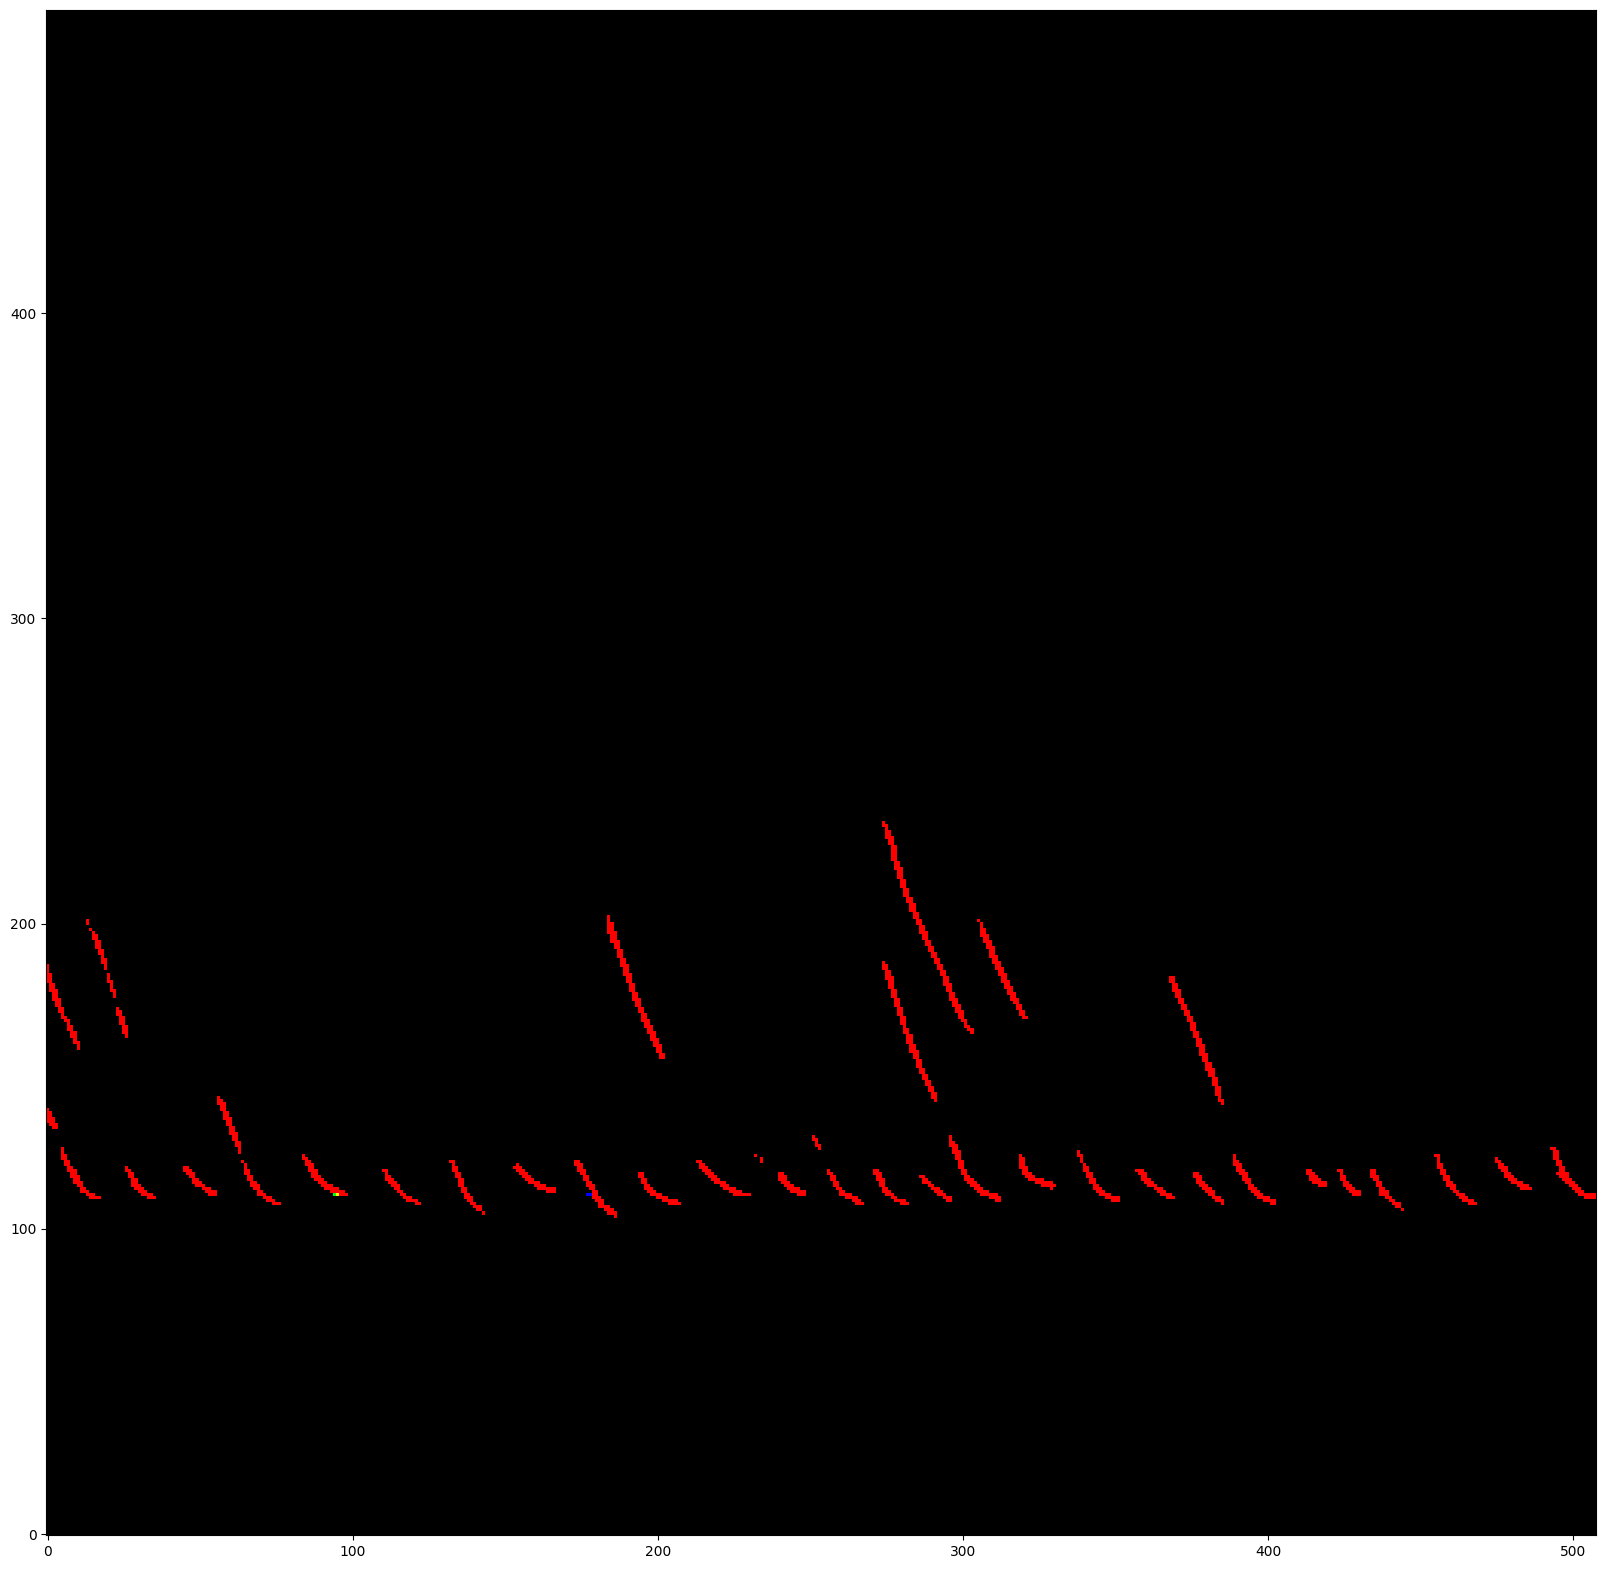

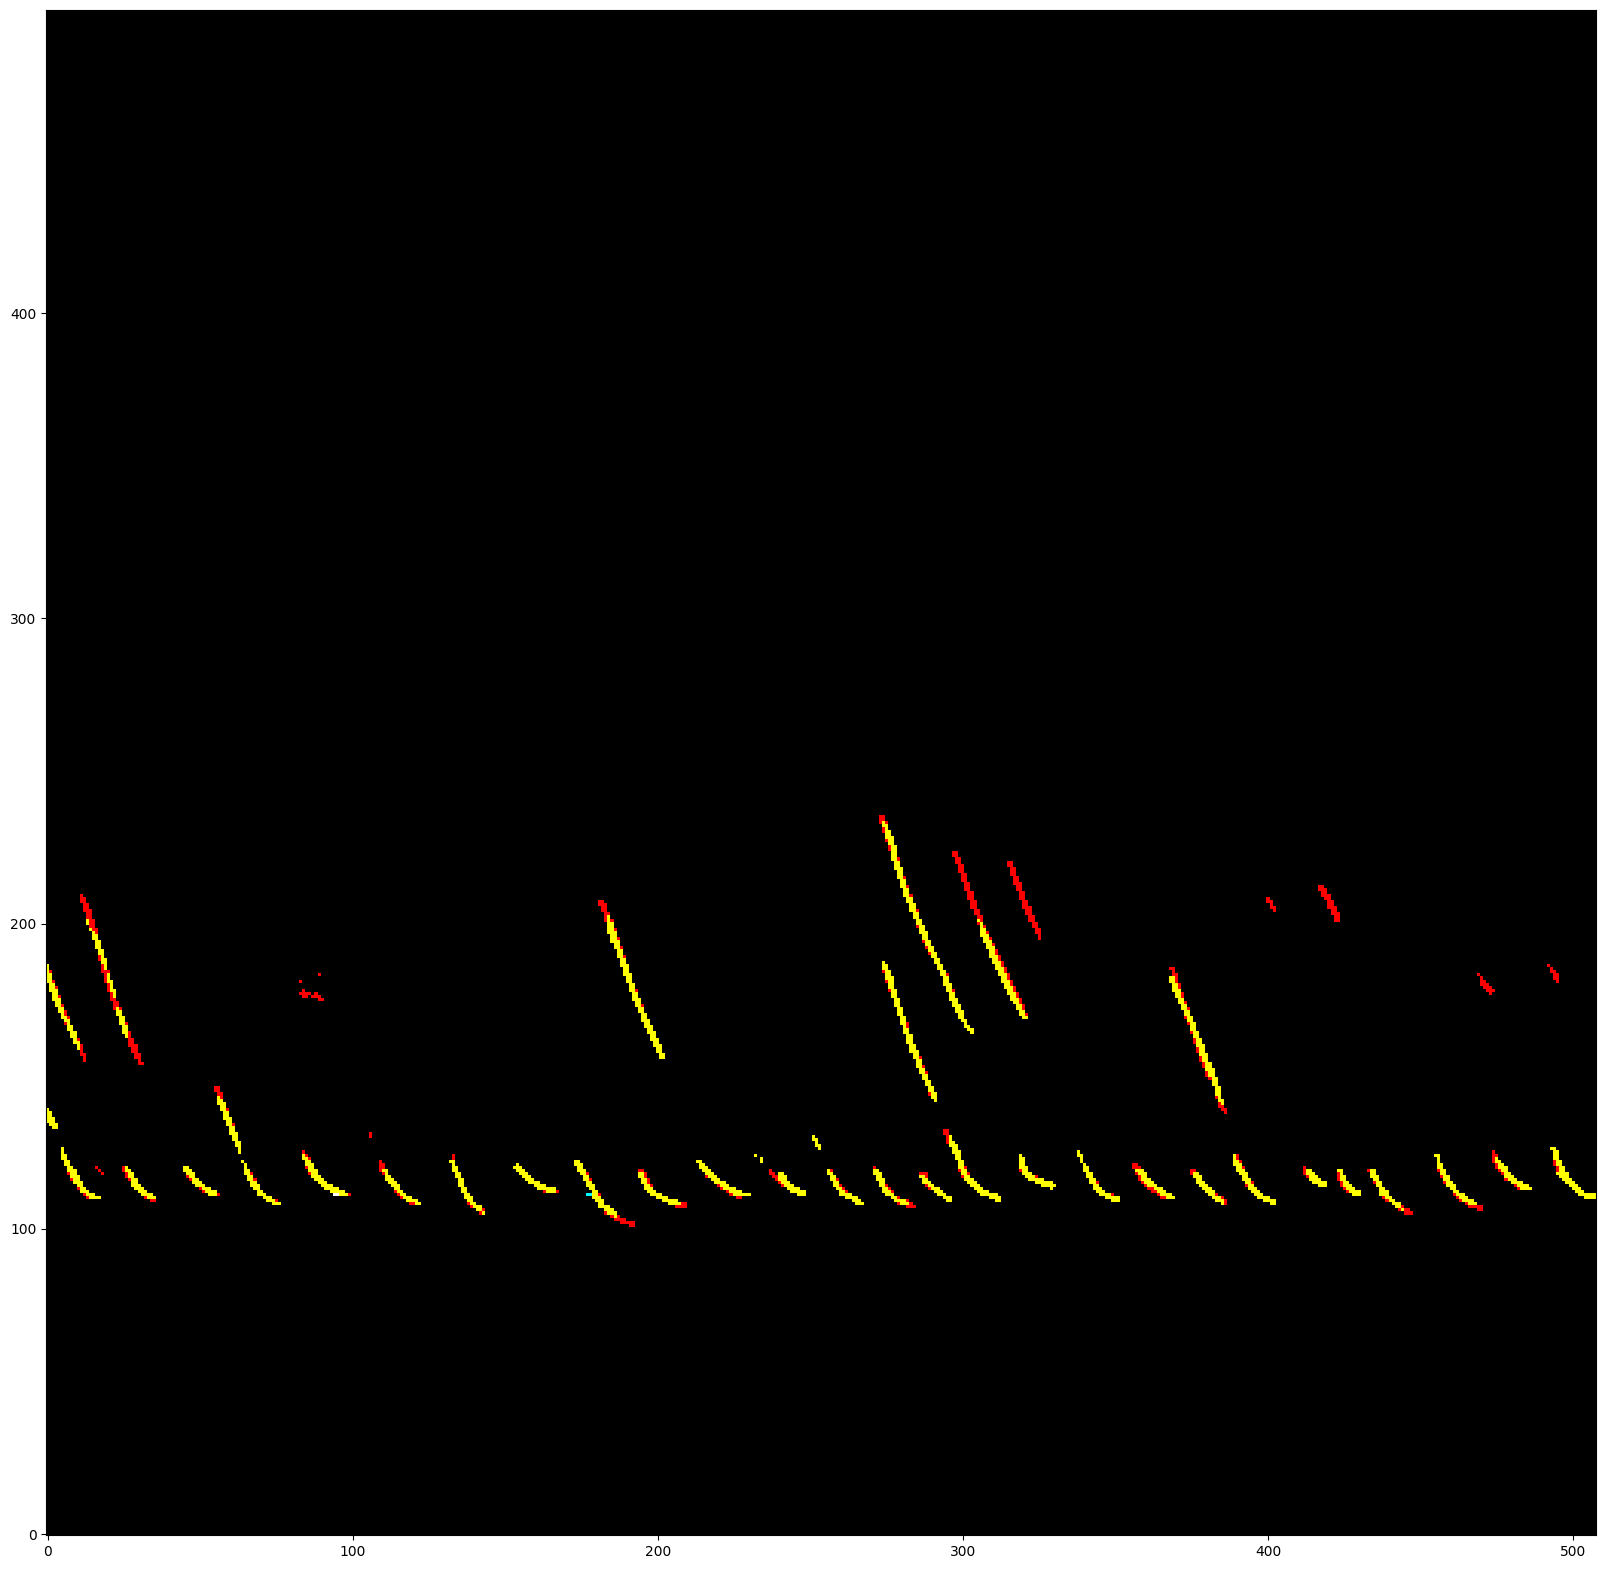

In [6]:
dilate_in_alongshore = np.zeros((1, 3, 1))  # 1x3x1 array to match our 3D input
dilate_in_alongshore[0, :, 0] = 1  # Make it [[[0]], [[1]], [[0]]]
dilated = ndimage.binary_dilation(ts, structure=dilate_in_alongshore)

plt.imshow(dilated[10])

plt.figure()
x = 100
plt.imshow(dilated[:, x, :].T, cmap='viridis')
plt.colorbar()

plt.figure(figsize=(20,20))
plt.imshow(np.stack([ts[:, x, :], np.zeros_like(ts[:, x, :]), 255 * dilated[:, x, :]]).T, cmap='bwr')


plt.figure(figsize=(20,20))
plt.imshow(np.stack([ts[:, x-1, :], ts[:, x, :], ts[:, x+1, :]]).T)


plt.figure(figsize=(20,20))
plt.imshow(np.stack([255*dilated[:, x-1, :], 255*dilated[:, x, :], 255*dilated[:, x+1, :]]).T)

In [7]:
labels, n_labels = ndimage.label(dilated)

label_nums = np.unique(labels)[1:]  # Skip 0 which is background
areas = ndimage.sum_labels(np.ones_like(labels), labels=labels, index=label_nums)
# plt.figure()
# plt.hist(areas, bins=1000)
# plt.xscale('log')

mask = np.zeros_like(labels)
for label, area in zip(label_nums, areas):
    if area >= 10:
        mask[labels == label] = label

# Get new labels without the small regions
filtered_labels, filtered_n_labels = ndimage.label(mask > 0)


(50.0, 200.0)

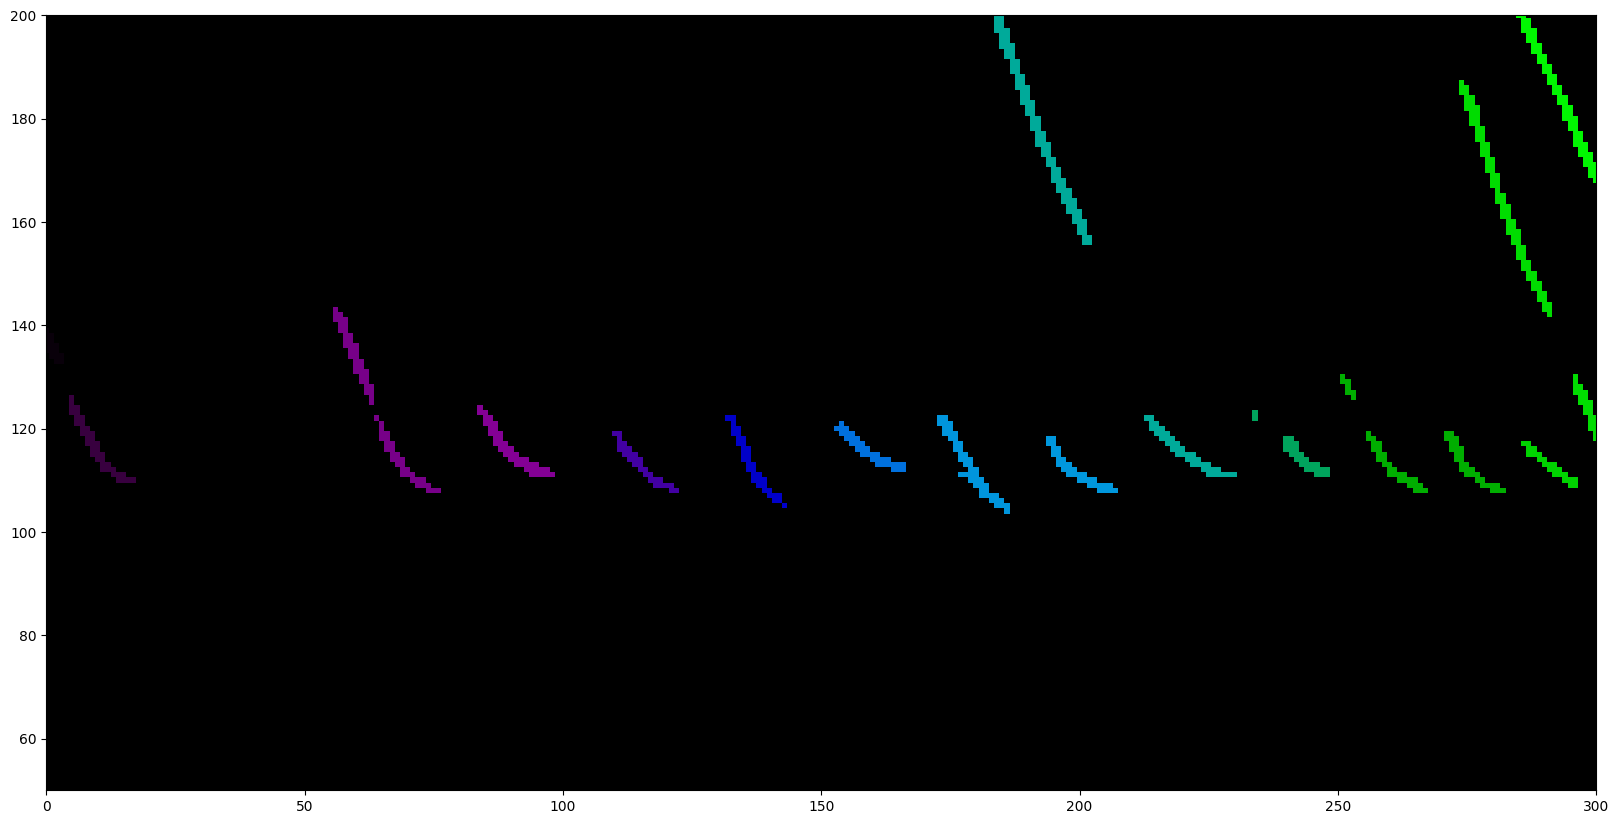

In [8]:
plt.figure(figsize=(20,20))
plt.imshow(filtered_labels[:, 100, :].T, cmap='nipy_spectral')
plt.xlim(0, 300)
plt.ylim(50, 200)

(50.0, 200.0)

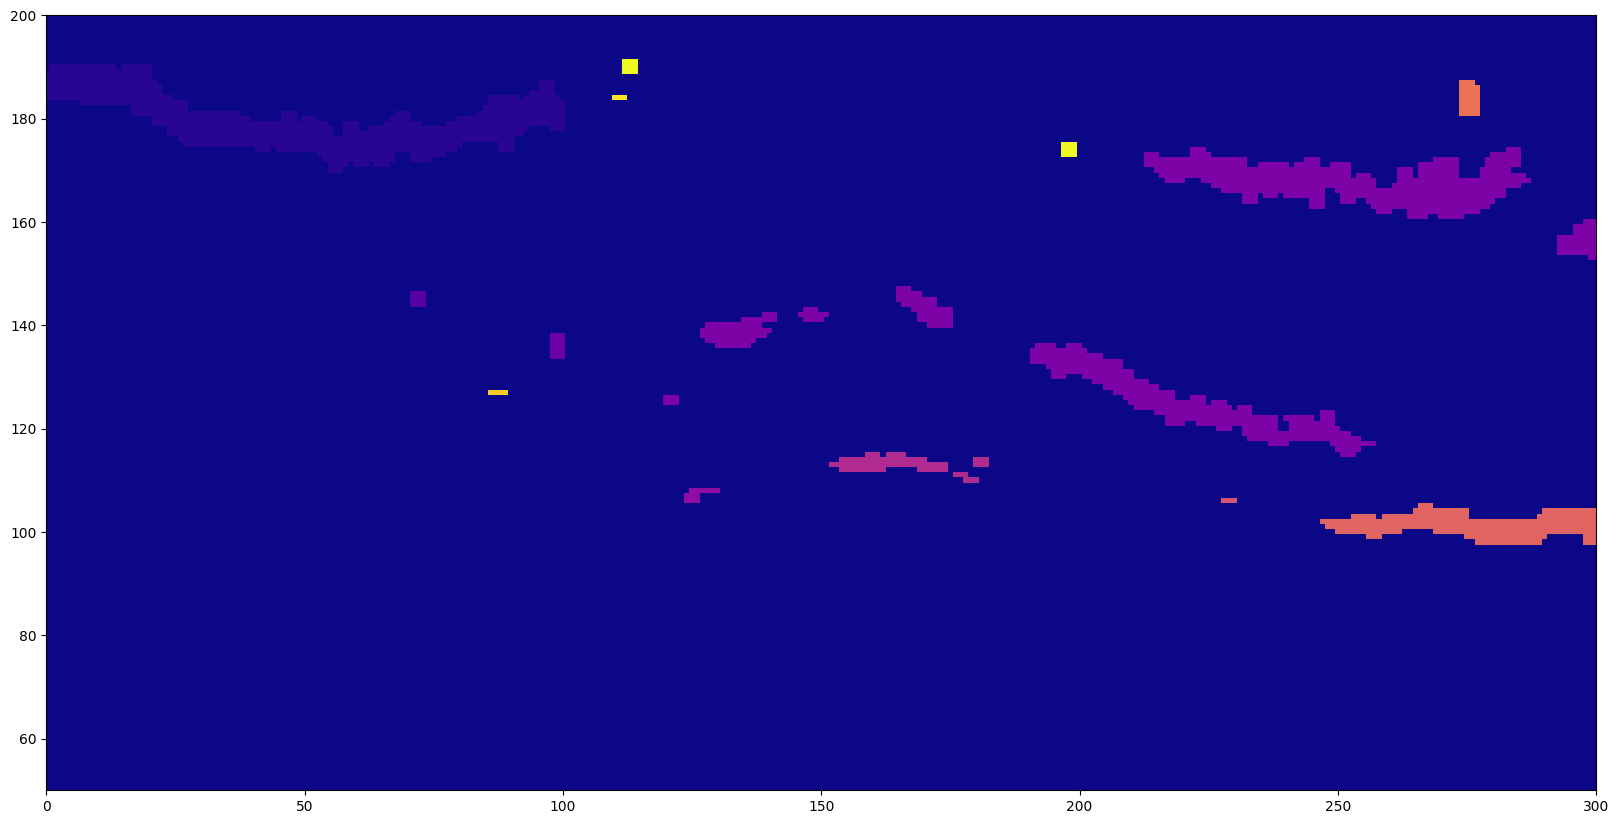

In [9]:
plt.figure(figsize=(20,20))
plt.imshow(filtered_labels[0].T, cmap='plasma', vmax=10)
plt.xlim(0, 300)
plt.ylim(50, 200)
plt.imshow(filtered_labels[1].T, cmap='plasma', vmax=20)
plt.xlim(0, 300)
plt.ylim(50, 200)

(50.0, 200.0)

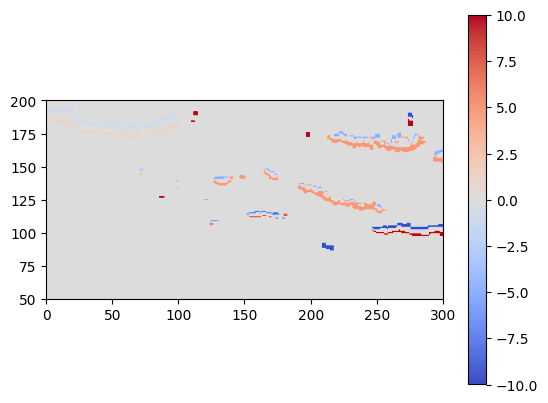

In [10]:
plt.imshow((filtered_labels[1]-filtered_labels[0]).T, cmap='coolwarm', vmin=-10, vmax=10)
plt.colorbar()
plt.xlim(0, 300)
plt.ylim(50, 200)


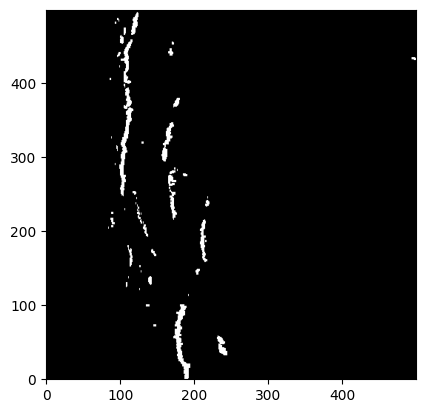

In [11]:
plt.imshow(dilated[0])

In [134]:
max_label = 0
crests = []
labeled = np.zeros_like(ts, dtype=int)

for frame in tqdm(range(dilated.shape[0])):
    labels, n_labels = ndimage.label(dilated[frame])
    labels += max_label
    label_nums = np.unique(labels)[1:]  # Skip 0 which is background
    areas = ndimage.sum_labels(np.ones_like(labels), labels=labels, index=label_nums)
    centroids = ndimage.center_of_mass(np.ones_like(labels), labels=labels, index=label_nums)

    for label, area, centroid in zip(label_nums, areas, centroids):
        if area <= 10:
            continue
        # Get mask for current label
        mask = labels == label
        
        # Find row and column indices where label exists
        rows, cols = np.where(mask)
        
        # Find the points that touch the bounding box edges
        left_point = (rows[np.argmin(cols)], np.min(cols))    # leftmost point
        right_point = (rows[np.argmax(cols)], np.max(cols))   # rightmost point
        top_point = (np.min(rows), cols[np.argmin(rows)])     # topmost point
        bottom_point = (np.max(rows), cols[np.argmax(rows)])  # bottommost point
        
        crests.append({
            'label': label,
            'frame': frame,
            'centroid': centroid,
            'alongshore_extent': (np.min(rows), np.max(rows)),
            'cross_shore_extent': (np.min(cols), np.max(cols)),
            'bbox': {
                'left': left_point,
                'right': right_point,
                'top': top_point,
                'bottom': bottom_point
            }
        })

    max_label = label_nums[-1]

100%|██████████| 508/508 [00:13<00:00, 37.46it/s]


In [14]:
from scipy import ndimage
import numpy as np

linear_crests = np.zeros_like(ts)

from bresenham import bresenham

for crest in crests:
    centroid = crest['centroid']
    x_min, x_max = crest['cross_shore_extent']
    y_min, y_max = crest['alongshore_extent']
    frame = crest['frame']
    
    # # Create coordinates for line
    # linear_crests[frame][(x_min+x_max)//2, y_min:y_max] = 1

    # print([0])
    bbox = crest['bbox']
    for y, x in np.array(list(bresenham(*bbox['top'], *bbox['left']))):
        linear_crests[frame, y, x] = 1

    for y, x in np.array(list(bresenham(*bbox['left'], *bbox['bottom']))):
            linear_crests[frame, y, x] = 1

    # plt.figure()
    # plt.scatter(*np.array(list(bresenham(x_max, y_max, x_min, y_min))).T)

    # break

   #  # Calculate number of points needed
   #  num_points = int(y_max - y_min) + 1
    
   #  # Create linearly spaced coordinates for both x and y
    
    
    
   #  y_coords = np.linspace(y_max, y_min, num_points)
   #  x_coords = np.linspace(x_min, x_max, num_points)
    
   #  # Round to nearest integer for indexing
   #  y_coords = y_coords.astype(int)
   #  x_coords = x_coords.astype(int)
    
   #  # Set the line pixels
   #  linear_crests[frame][x_coords, y_coords] = 1
    


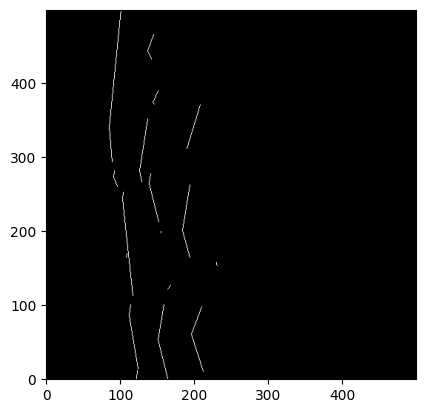

In [15]:
plt.imshow(255 * linear_crests[10])

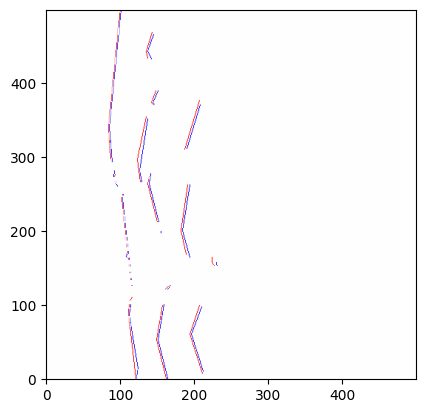

In [16]:
plt.imshow(255 * linear_crests[11] - 255 * linear_crests[10], cmap='bwr')

In [17]:
import sys; sys.path.append('..'); from notebooks.video_io import *

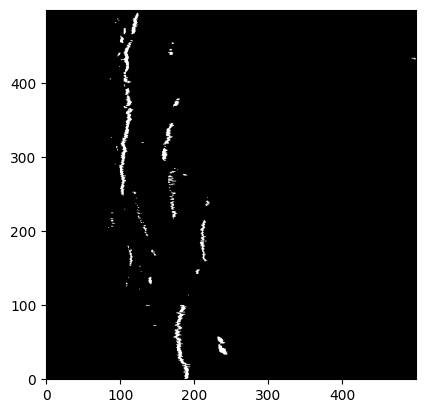

In [19]:
plt.imshow(ts[0])

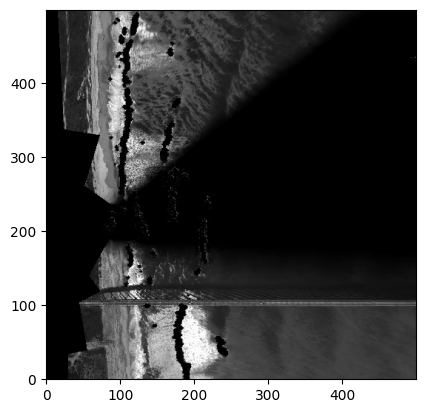

In [20]:
plt.imshow(frames[0])

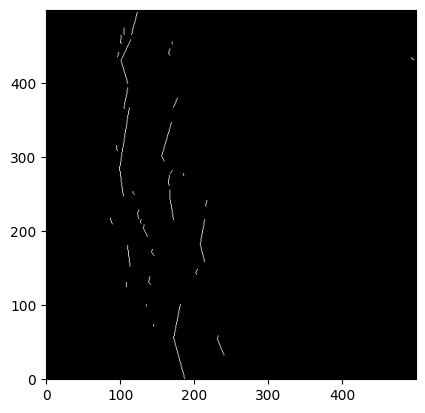

In [21]:
plt.imshow(linear_crests[0])

In [135]:
from scipy import ndimage
import numpy as np
from numpy.polynomial import Polynomial
from bresenham import bresenham

def rasterize_polynomial(points, image_shape, thickness=3):
    """
    Rasterize a polynomial curve given by a set of points onto a binary image with specified thickness.
    
    Args:
        points: Nx2 array of (y, x) coordinates
        image_shape: Tuple of (height, width) for the output image
        thickness: Integer specifying the thickness of the curve in pixels (odd number recommended)
    
    Returns:
        Binary mask with the rasterized polynomial
    """
    # Sort points by y coordinate
    points = points[np.argsort(points[:, 0])]
    
    # Fit quadratic polynomial
    poly = Polynomial.fit(points[:, 0], points[:, 1], deg=2)
    
    # Generate dense set of y coordinates
    y_dense = np.arange(points[:, 0].min(), points[:, 0].max() + 1)
    
    # Calculate corresponding x coordinates
    x_dense = poly(y_dense)
    
    # Round to nearest integer
    x_dense = np.round(x_dense).astype(int)
    
    # Create mask
    mask = np.zeros(image_shape, dtype=bool)
    
    # Calculate offset range for thickness
    offset_range = thickness // 2
    
    # Generate offsets for both x and y directions
    y_offsets, x_offsets = np.meshgrid(
        np.arange(-offset_range, offset_range + 1),
        np.arange(-offset_range, offset_range + 1)
    )
    
    # Flatten the offset arrays
    y_offsets = y_offsets.flatten()
    x_offsets = x_offsets.flatten()
    
    # For each point on the curve, add thickness
    for y, x in zip(y_dense, x_dense):
        # Add offsets to current point
        y_thick = y + y_offsets
        x_thick = x + x_offsets
        
        # Filter out points outside image bounds
        valid = (
            (x_thick >= 0) & (x_thick < image_shape[1]) &
            (y_thick >= 0) & (y_thick < image_shape[0])
        )
        
        # Set points in mask
        mask[y_thick[valid], x_thick[valid]] = True
    
    return mask
def generate_polynomial_masks(crests, shape):
    """
    Generate masks for all crests using polynomial curves.
    
    Args:
        crests: List of crest dictionaries containing bbox
        shape: Tuple of (frames, height, width) for the output array
    
    Returns:
        Array of masks with polynomial curves
    """
    polynomial_crests = np.zeros(shape, dtype=bool)
    
    for crest in crests:
        frame = crest['frame']
        bbox = crest['bbox']
        
        # Collect points from top to left to bottom
        points = []
        points.extend(np.array(list(bresenham(*bbox['top'], *bbox['left']))))
        points.extend(np.array(list(bresenham(*bbox['left'], *bbox['bottom']))))
        points = np.array(points)
        
        # Generate and add mask
        mask = rasterize_polynomial(points, shape[1:])
        polynomial_crests[frame] |= mask
    
    return polynomial_crests

In [136]:
polynomial_crests = generate_polynomial_masks(crests, ts.shape)
write_sequence_to_mp4(frames, fname='linear_crests.mp4',
                      data=polynomial_crests,
                        fn=show_breakers_on_frame, 
                        transpose=True
                      )

/Users/mleclair/.pyenv/versions/dunex_pytorch/lib/python3.12/site-packages/numpy/polynomial/polynomial.py:1362: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
100%|██████████| 508/508 [00:02<00:00, 236.94it/s]


In [153]:
import numpy as np
from scipy.optimize import linear_sum_assignment

class CrestTracker:
    def __init__(self, max_distance=50, max_gap=2, min_frames=4):
        self.max_distance = max_distance
        self.max_gap = max_gap  # Maximum number of frames to look ahead for matches
        self.min_frames = min_frames  # Minimum track length to keep
        self.tracks = []
        self.next_track_id = 0
    
    def _compute_cost_matrix(self, current_crests, next_crests):
        """Compute cost matrix between current and next frame crests based on centroid distance."""
        cost_matrix = np.zeros((len(current_crests), len(next_crests)))
        
        for i, crest1 in enumerate(current_crests):
            for j, crest2 in enumerate(next_crests):
                y1, x1 = crest1['centroid']
                y2, x2 = crest2['centroid']
                distance = np.sqrt((y2-y1)**2 + (x2-x1)**2)
                cost_matrix[i,j] = distance if distance <= self.max_distance else 1e6
                
        return cost_matrix
    
    def _get_active_tracks(self, current_frame):
        """Return list of tracks that were active recently (within max_gap frames)"""
        active_tracks = []
        for track in self.tracks:
            last_frame = track['frames'][-1]
            if current_frame - last_frame <= self.max_gap:
                active_tracks.append(track)
        return active_tracks
    
    def update(self, crests_by_frame):
        """Update tracks with new frame of detections."""
        frames = sorted(crests_by_frame.keys())
        
        # Initialize tracks for first frame
        if frames and frames[0] not in {track['frames'][0] for track in self.tracks}:
            for crest in crests_by_frame[frames[0]]:
                self.tracks.append({
                    'id': self.next_track_id,
                    'crests': [crest],
                    'frames': [frames[0]]
                })
                self.next_track_id += 1
        
        # Process subsequent frames
        for frame_idx in range(len(frames)-1):
            current_frame = frames[frame_idx]
            next_frame = frames[frame_idx+1]
            
            next_crests = crests_by_frame[next_frame]
            if not next_crests:
                continue
            
            # Get active tracks from current and previous frames
            active_tracks = self._get_active_tracks(current_frame)
            if not active_tracks:
                # If no active tracks, create new ones for all crests
                for crest in next_crests:
                    self.tracks.append({
                        'id': self.next_track_id,
                        'crests': [crest],
                        'frames': [next_frame]
                    })
                    self.next_track_id += 1
                continue
            
            # Get last known crests from active tracks
            current_tracked_crests = [track['crests'][-1] for track in active_tracks]
            
            # Compute cost matrix
            cost_matrix = self._compute_cost_matrix(current_tracked_crests, next_crests)
            
            # Use Hungarian algorithm
            row_ind, col_ind = linear_sum_assignment(cost_matrix)
            
            # Keep track of matched crests
            matched_next_crests = set()
            
            # Process assignments
            for i, j in zip(row_ind, col_ind):
                if cost_matrix[i,j] < self.max_distance:
                    track = active_tracks[i]
                    last_frame = track['frames'][-1]
                    
                    # Fill in gaps if necessary
                    for gap_frame in range(last_frame + 1, next_frame):
                        track['frames'].append(gap_frame)
                        # Interpolate crest position for gap frames
                        alpha = (gap_frame - last_frame) / (next_frame - last_frame)
                        y1, x1 = track['crests'][-1]['centroid']
                        y2, x2 = next_crests[j]['centroid']
                        interpolated_crest = {
                            'centroid': (
                                y1 + alpha * (y2 - y1),
                                x1 + alpha * (x2 - x1)
                            ),
                            # Copy other properties from last known crest
                            **{k: v for k, v in track['crests'][-1].items() 
                               if k != 'centroid'}
                        }
                        track['crests'].append(interpolated_crest)
                    
                    # Add the actual detection
                    track['frames'].append(next_frame)
                    track['crests'].append(next_crests[j])
                    matched_next_crests.add(j)
            
            # Create new tracks for unmatched detections
            for j, crest in enumerate(next_crests):
                if j not in matched_next_crests:
                    self.tracks.append({
                        'id': self.next_track_id,
                        'crests': [crest],
                        'frames': [next_frame]
                    })
                    self.next_track_id += 1
        
        # Filter out short tracks
        self.tracks = [track for track in self.tracks 
                      if len(track['frames']) >= self.min_frames]
        
        return self.tracks

    def rasterize_all_tracks(self, shape, label=False):
        mask = np.zeros(shape, dtype=bool if not label else int)
        for i, track in enumerate(self.tracks):
            for frame, crest in zip(track['frames'], track['crests']):
                bbox = crest['bbox']
                points = []
                points.extend(np.array(list(bresenham(*bbox['top'], *bbox['left']))))
                points.extend(np.array(list(bresenham(*bbox['left'], *bbox['bottom']))))
                points = np.array(points)
                poly_mask = rasterize_polynomial(points, shape[1:])
                mask[frame][poly_mask] = i
        return mask
        
    def rasterize_tracks(self, shape):
        """Optional method to generate masks only when needed"""
        track_masks = {}
        for track in self.tracks:
            mask = np.zeros(shape, dtype=bool)
            for frame, crest in zip(track['frames'], track['crests']):
                bbox = crest['bbox']
                points = []
                points.extend(np.array(list(bresenham(*bbox['top'], *bbox['left']))))
                points.extend(np.array(list(bresenham(*bbox['left'], *bbox['bottom']))))
                points = np.array(points)
                poly_mask = rasterize_polynomial(points, shape[1:])
                mask[frame] |= poly_mask
            track_masks[track['id']] = mask
        return track_masks
    
    def _calculate_polynomial_speed(self, points1, points2):
        """
        Calculate average speed between two polynomial curves by sampling points
        
        Args:
            points1, points2: Arrays of (y,x) coordinates for consecutive frames
        Returns:
            float: Average speed (distance/frame) between the curves
        """
        # Sample 20 evenly spaced points along each curve
        n_samples = 20
        
        # Ensure points are sorted by y coordinate
        points1 = points1[np.argsort(points1[:, 0])]
        points2 = points2[np.argsort(points2[:, 0])]
        
        # Fit polynomials
        poly1 = Polynomial.fit(points1[:, 0], points1[:, 1], deg=2)
        poly2 = Polynomial.fit(points2[:, 0], points2[:, 1], deg=2)
        
        # Generate sample points
        y1_min, y1_max = points1[:, 0].min(), points1[:, 0].max()
        y2_min, y2_max = points2[:, 0].min(), points2[:, 0].max()
        
        y1_samples = np.linspace(y1_min, y1_max, n_samples)
        y2_samples = np.linspace(y2_min, y2_max, n_samples)
        
        x1_samples = poly1(y1_samples)
        x2_samples = poly2(y2_samples)
        
        # Calculate distances between corresponding points
        distances = []
        for i in range(n_samples):
            # Find closest point in the other curve
            distances_to_curve2 = np.sqrt(
                (x1_samples[i] - x2_samples) ** 2 + 
                (y1_samples[i] - y2_samples) ** 2
            )
            distances.append(np.min(distances_to_curve2))
            
        return np.mean(distances)
    
    
    def _calculate_normal_speed(self, points1, points2):
        """
        Calculate speed normal to the first polynomial curve
        
        Args:
            points1, points2: Arrays of (y,x) coordinates for consecutive frames
        Returns:
            float: Average normal speed (distance/frame)
        """
        # Ensure points are sorted by y coordinate
        points1 = points1[np.argsort(points1[:, 0])]
        points2 = points2[np.argsort(points2[:, 0])]
        
        # Fit polynomials
        poly1 = Polynomial.fit(points1[:, 0], points1[:, 1], deg=2)
        poly2 = Polynomial.fit(points2[:, 0], points2[:, 1], deg=2)
        
        # Sample points along first curve
        n_samples = 20
        y1_min, y1_max = points1[:, 0].min(), points1[:, 0].max()
        y_samples = np.linspace(y1_min, y1_max, n_samples)
        
        # Get points on both curves
        x1_samples = poly1(y_samples)
        x2_samples = poly2(y_samples)
        
        # Calculate derivative of first polynomial
        poly1_deriv = poly1.deriv()
        slopes = poly1_deriv(y_samples)
        
        # Calculate normal vectors at each point
        # Normal vector is (-dy, dx) normalized
        normals = np.vstack([-slopes, np.ones_like(slopes)]).T
        normals /= np.sqrt(np.sum(normals**2, axis=1))[:, np.newaxis]
        
        # Calculate displacement vectors
        displacements = np.vstack([x2_samples - x1_samples, 
                                 y_samples - y_samples]).T
        
        # Project displacements onto normals
        normal_speeds = np.abs(np.sum(displacements * normals, axis=1))
        
        return np.mean(normal_speeds)
    
    def get_track_info(self):
        """Return track information including normal speeds"""
        track_info = {}
        for track in self.tracks:
            frames = track['frames']
            crests = track['crests']
            
            # Calculate speeds
            centroid_speeds = []
            poly_speeds = []
            normal_speeds = []
            
            for i in range(len(frames) - 1):
                dt = frames[i+1] - frames[i]
                
                # Centroid speed
                y1, x1 = crests[i]['centroid']
                y2, x2 = crests[i+1]['centroid']
                dx = x2 - x1
                dy = y2 - y1
                speed = np.sqrt(dx**2 + dy**2) / dt
                
                centroid_speeds.append({
                    'frame': frames[i],
                    'dx': dx/dt,
                    'dy': dy/dt,
                    'speed': speed
                })
                
                # Get points for polynomial speeds
                contacts1 = crests[i]['bbox']
                contacts2 = crests[i+1]['bbox']
                
                points1 = []
                points1.extend(np.array(list(bresenham(*contacts1['top'], *contacts1['left']))))
                points1.extend(np.array(list(bresenham(*contacts1['left'], *contacts1['bottom']))))
                points1 = np.array(points1)
                
                points2 = []
                points2.extend(np.array(list(bresenham(*contacts2['top'], *contacts2['left']))))
                points2.extend(np.array(list(bresenham(*contacts2['left'], *contacts2['bottom']))))
                points2 = np.array(points2)
                
                # Calculate both total and normal speeds
                poly_speed = self._calculate_polynomial_speed(points1, points2) / dt
                normal_speed = self._calculate_normal_speed(points1, points2) / dt
                
                poly_speeds.append({
                    'frame': frames[i],
                    'speed': poly_speed
                })
                
                normal_speeds.append({
                    'frame': frames[i],
                    'speed': normal_speed
                })
            
            track_info[track['id']] = {
                'frames': frames,
                'bbox': [crest['bbox'] for crest in crests],
                'centroids': [crest['centroid'] for crest in crests],
                'centroid_speeds': centroid_speeds,
                'polynomial_speeds': poly_speeds,
                'normal_speeds': normal_speeds
            }
            
        return track_info

    def get_speed_statistics(self):
        """Calculate summary statistics for speeds across all tracks"""
        centroid_speeds = []
        poly_speeds = []
        
        track_info = self.get_track_info()
        
        for track_id, info in track_info.items():
            centroid_speeds.extend([s['speed'] for s in info['centroid_speeds']])
            poly_speeds.extend([s['speed'] for s in info['polynomial_speeds']])
            
        return {
            'centroid_speeds': {
                'mean': np.mean(centroid_speeds),
                'std': np.std(centroid_speeds),
                'min': np.min(centroid_speeds),
                'max': np.max(centroid_speeds)
            },
            'polynomial_speeds': {
                'mean': np.mean(poly_speeds),
                'std': np.std(poly_speeds),
                'min': np.min(poly_speeds),
                'max': np.max(poly_speeds)
            }
        }



In [154]:
crests_by_frame = {}
for crest in crests:  # assuming crests is your list of crest dictionaries
    frame = crest['frame']
    if frame not in crests_by_frame:
        crests_by_frame[frame] = []
    crests_by_frame[frame].append(crest)

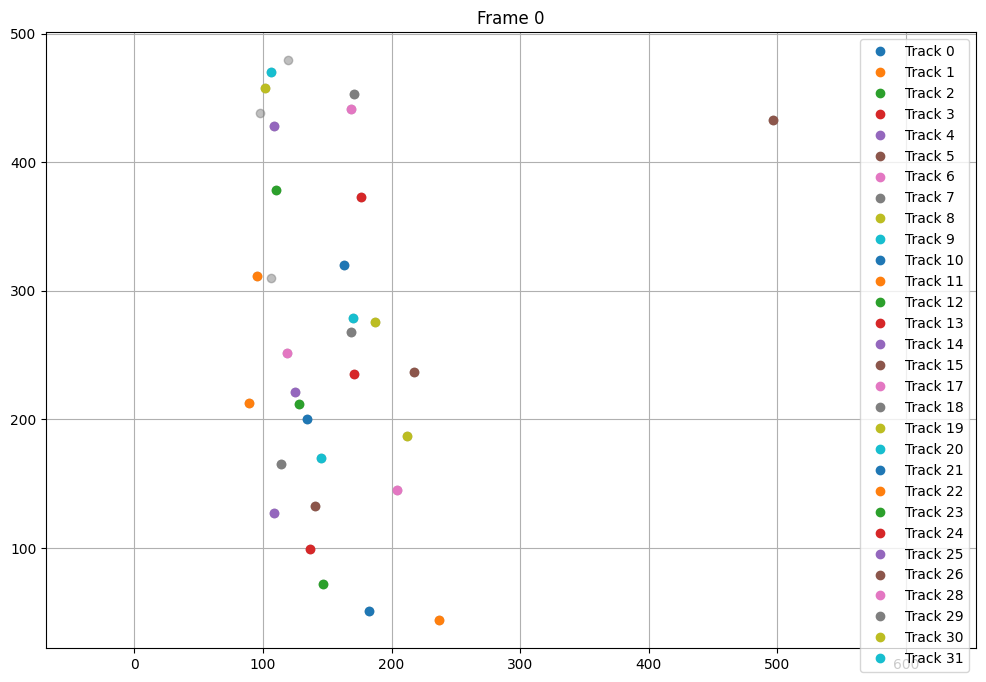

Total number of tracks: 320
Track 0: 121 frames, frames 0 to 120
Track 1: 48 frames, frames 0 to 47
Track 2: 7 frames, frames 0 to 6
Track 3: 7 frames, frames 0 to 6
Track 4: 47 frames, frames 0 to 46


In [155]:


# Initialize and run tracker
tracker = CrestTracker(max_distance=100)  # adjust max_distance based on your data
tracks = tracker.update(crests_by_frame)

# Visualize results - here's a simple visualization for one frame
import matplotlib.pyplot as plt

def visualize_tracks(tracks, frame_number):
    plt.figure(figsize=(12, 8))
    
    # Plot all crests in this frame in gray
    if frame_number in crests_by_frame:
        for crest in crests_by_frame[frame_number]:
            y, x = crest['centroid']
            plt.plot(x, y, 'o', color='gray', alpha=0.5)
    
    # Plot tracked crests with different colors
    for track in tracks:
        if frame_number in track['frames']:
            idx = track['frames'].index(frame_number)
            crest = track['crests'][idx]
            y, x = crest['centroid']
            plt.plot(x, y, 'o', label=f'Track {track["id"]}')
    
    plt.title(f'Frame {frame_number}')
    plt.legend()
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# Visualize a specific frame
frame_to_show = min(crests_by_frame.keys())  # show first frame
visualize_tracks(tracks, frame_to_show)

# Print some statistics
print(f"Total number of tracks: {len(tracks)}")
for track in tracks[:5]:  # Show first 5 tracks
    print(f"Track {track['id']}: {len(track['frames'])} frames, "
          f"frames {track['frames'][0]} to {track['frames'][-1]}")


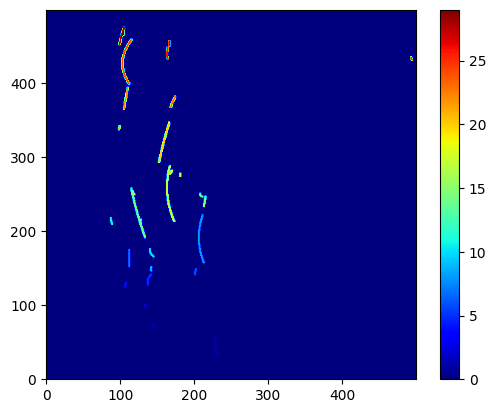

In [156]:
plt.imshow(track_labels[1], cmap='jet')
plt.colorbar()

In [157]:
track_labels = tracker.rasterize_all_tracks(frames.shape, label=True)

In [143]:
from notebooks.video_io import *

  
write_sequence_to_mp4(frames, fname='tracke_crests.mp4',
                      data=track_labels, 
                      fn=show_labels_on_frame(track_labels),
                      transpose=True)

100%|██████████| 508/508 [00:02<00:00, 188.04it/s]


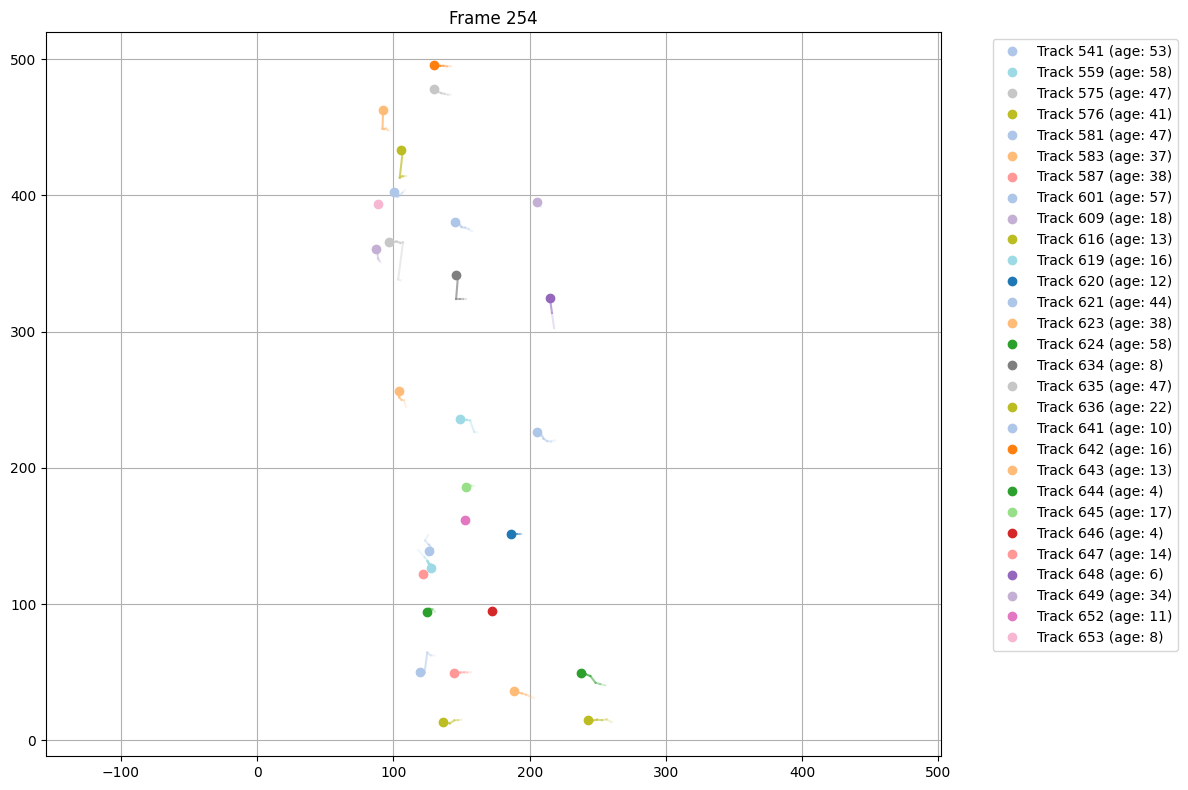

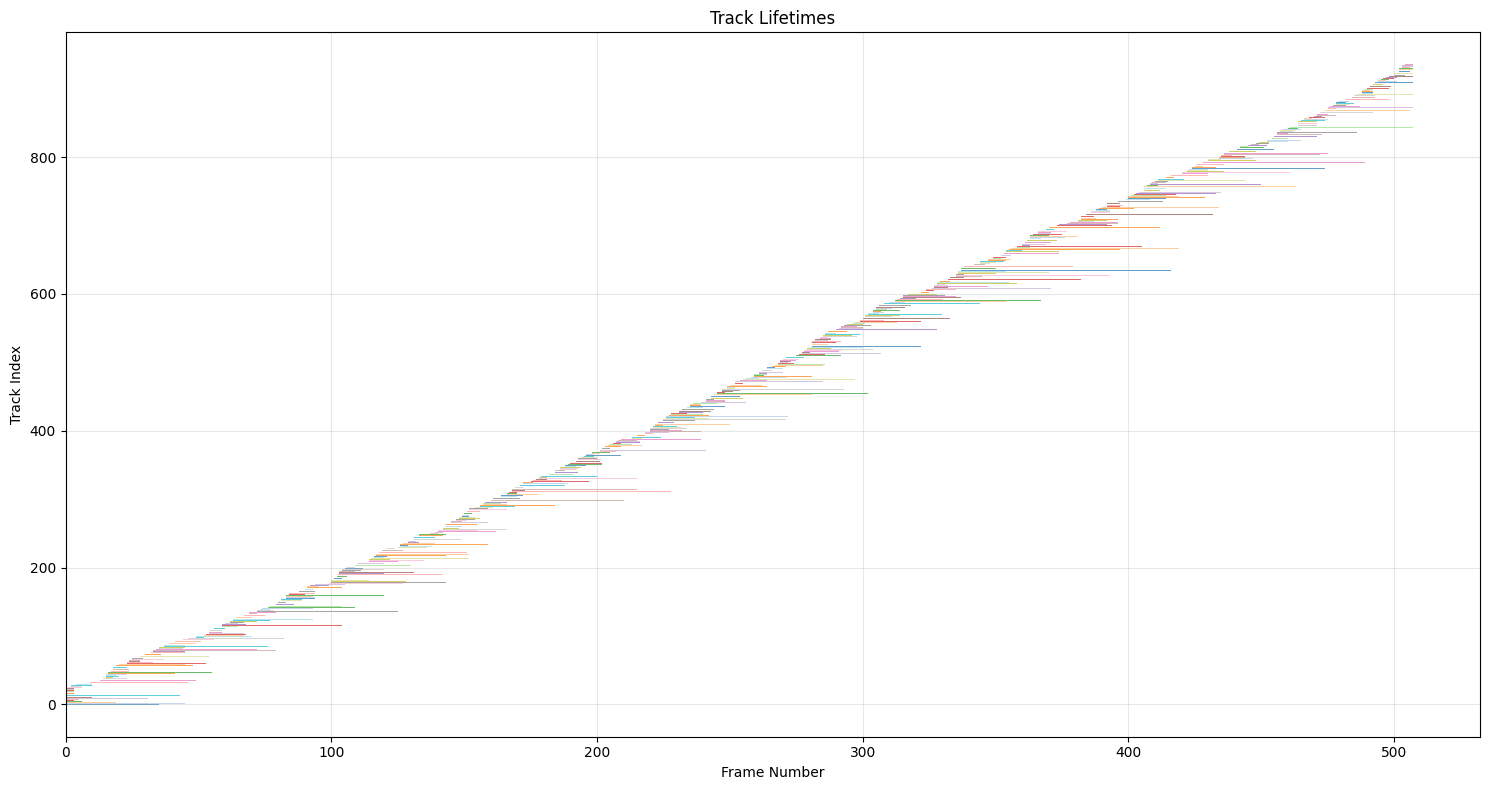

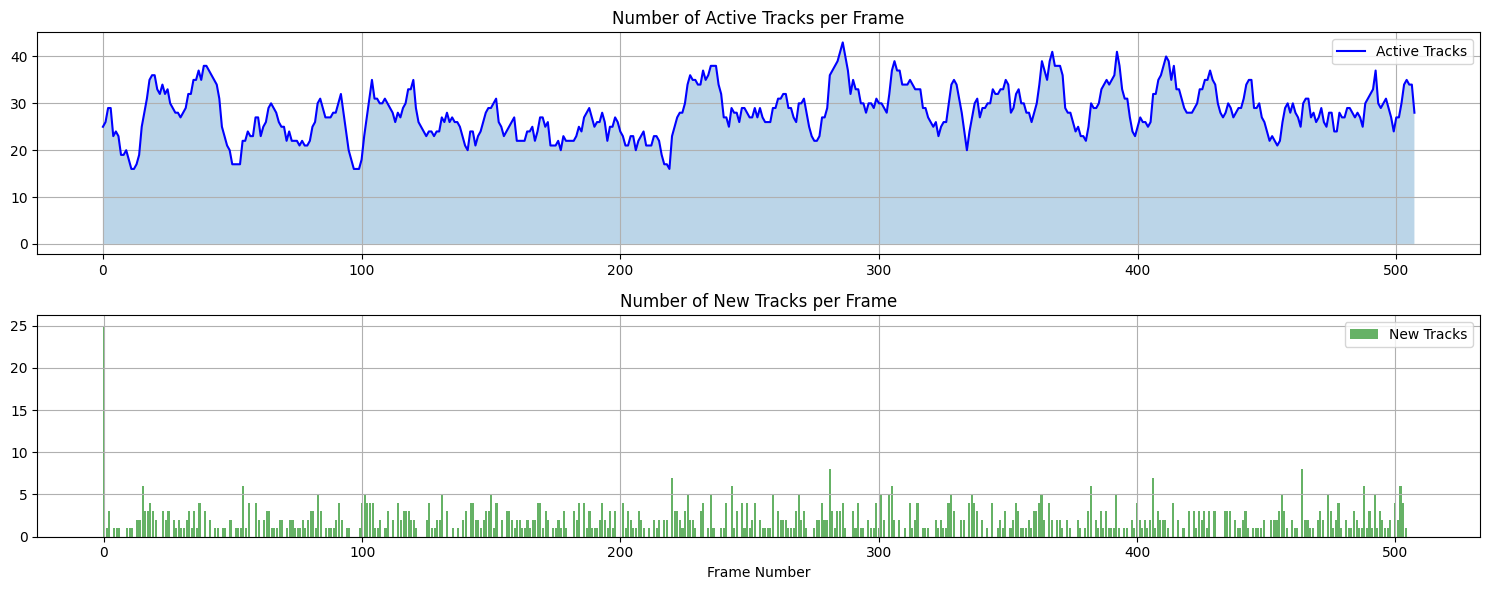

Total number of tracks: 936
Average track length: 15.3 frames
Longest track: 81 frames
Shortest track: 4 frames


In [144]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

def visualize_tracks_with_history(tracks, frame_number, window_size=5):
    """Visualize tracks with history trails"""
    plt.figure(figsize=(12, 8))
    
    # Plot recent history for each track
    for track in tracks:
        if frame_number in track['frames']:
            current_idx = track['frames'].index(frame_number)
            
            # Get history indices
            start_idx = max(0, current_idx - window_size)
            history_frames = track['frames'][start_idx:current_idx + 1]
            history_crests = track['crests'][start_idx:current_idx + 1]
            
            # Plot history trail
            ys = [crest['centroid'][0] for crest in history_crests]
            xs = [crest['centroid'][1] for crest in history_crests]
            
            # Plot trail with increasing alpha
            alphas = np.linspace(0.2, 1.0, len(xs))
            for i in range(len(xs)-1):
                plt.plot(xs[i:i+2], ys[i:i+2], '-', alpha=alphas[i], 
                        color=plt.cm.tab20(track['id'] % 20))
            
            # Plot current position
            plt.plot(xs[-1], ys[-1], 'o', 
                    label=f'Track {track["id"]} (age: {len(track["frames"])})',
                    color=plt.cm.tab20(track['id'] % 20))
            
            # Mark new tracks (created in last 2 frames)
            if len(track['frames']) <= 2:
                plt.plot(xs[-1], ys[-1], 'k*', markersize=15, alpha=0.5)

    plt.title(f'Frame {frame_number}')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

def plot_track_lifetimes(tracks):
    """Visualize track lifetimes as horizontal bars"""
    plt.figure(figsize=(15, 8))
    
    # Sort tracks by start frame
    sorted_tracks = sorted(tracks, key=lambda x: x['frames'][0])
    
    for i, track in enumerate(sorted_tracks):
        start_frame = track['frames'][0]
        end_frame = track['frames'][-1]
        duration = end_frame - start_frame
        
        plt.barh(i, duration, left=start_frame, 
                color=plt.cm.tab20(track['id'] % 20), alpha=0.7)
        # plt.text(start_frame, i, f'Track {track["id"]}', 
        #         ha='right', va='center', fontsize=8)

    plt.title('Track Lifetimes')
    plt.xlabel('Frame Number')
    plt.ylabel('Track Index')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_track_statistics(tracks, total_frames):
    """Plot statistics about active tracks and new tracks per frame"""
    frames = range(total_frames)
    active_tracks = []
    new_tracks = []
    
    for frame in frames:
        # Count active tracks
        active = sum(1 for track in tracks 
                    if track['frames'][0] <= frame <= track['frames'][-1])
        active_tracks.append(active)
        
        # Count new tracks
        new = sum(1 for track in tracks if track['frames'][0] == frame)
        new_tracks.append(new)
    
    plt.figure(figsize=(15, 6))
    
    plt.subplot(2, 1, 1)
    plt.plot(frames, active_tracks, '-b', label='Active Tracks')
    plt.fill_between(frames, active_tracks, alpha=0.3)
    plt.title('Number of Active Tracks per Frame')
    plt.grid(True)
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.bar(frames, new_tracks, color='g', alpha=0.6, label='New Tracks')
    plt.title('Number of New Tracks per Frame')
    plt.xlabel('Frame Number')
    plt.grid(True)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

# Example usage:
def analyze_tracking(tracker, crests_by_frame):
    """Run tracking and show all visualizations"""
    tracks = tracker.update(crests_by_frame)
    total_frames = max(crests_by_frame.keys()) + 1
    
    # Show tracking for a specific frame
    frame_to_show = total_frames // 2  # middle frame
    visualize_tracks_with_history(tracks, frame_to_show)
    
    # Show track lifetimes
    plot_track_lifetimes(tracks)
    
    # Show tracking statistics
    plot_track_statistics(tracks, total_frames)
    
    # Print summary statistics
    print(f"Total number of tracks: {len(tracks)}")
    print(f"Average track length: {np.mean([len(track['frames']) for track in tracks]):.1f} frames")
    print(f"Longest track: {max(len(track['frames']) for track in tracks)} frames")
    print(f"Shortest track: {min(len(track['frames']) for track in tracks)} frames")

# Run the analysis
tracker = CrestTracker(max_distance=30)  # adjust max_distance as needed
analyze_tracking(tracker, crests_by_frame)

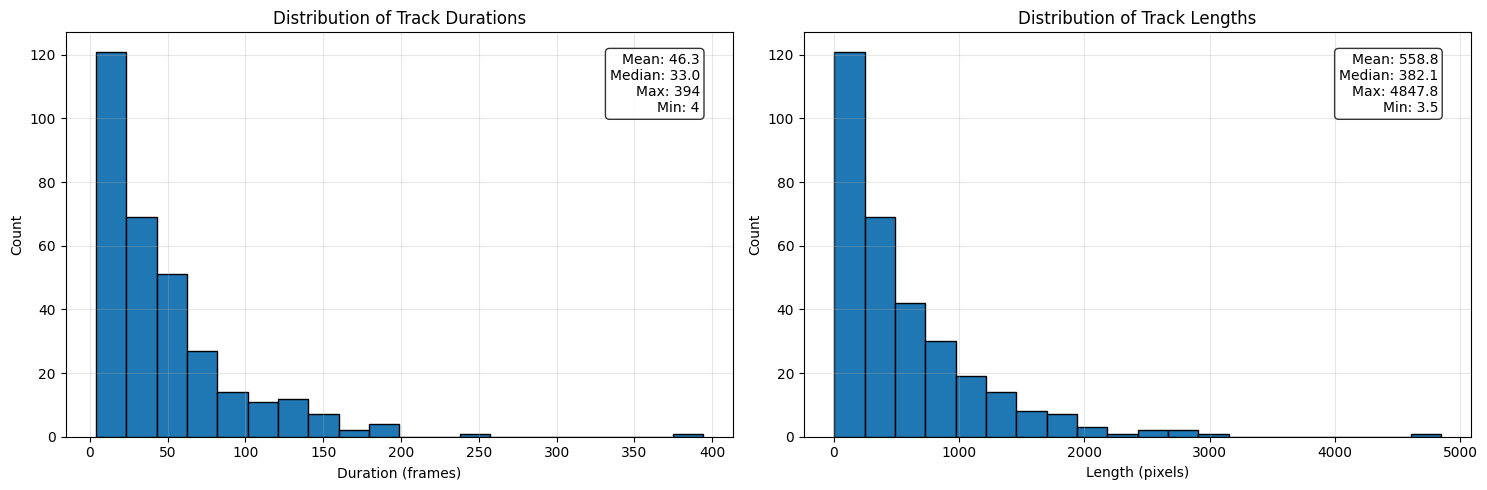


Total number of tracks: 320
Number of tracks lasting > 10 frames: 254
Number of tracks lasting > 20 frames: 207


In [145]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_track_statistics(tracks):
    """
    Create histograms of track durations and lengths
    """
    # Calculate track durations (in frames)
    durations = [len(track['frames']) for track in tracks]
    
    # Calculate track lengths (spatial distance covered)
    lengths = []
    for track in tracks:
        # Get all centroids
        centroids = np.array([crest['centroid'] for crest in track['crests']])
        # Calculate total path length
        diffs = np.diff(centroids, axis=0)
        length = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
        lengths.append(length)
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Plot duration histogram
    ax1.hist(durations, bins=20, edgecolor='black')
    ax1.set_title('Distribution of Track Durations')
    ax1.set_xlabel('Duration (frames)')
    ax1.set_ylabel('Count')
    ax1.grid(True, alpha=0.3)
    
    # Add statistics as text
    duration_stats = f'Mean: {np.mean(durations):.1f}\n'
    duration_stats += f'Median: {np.median(durations):.1f}\n'
    duration_stats += f'Max: {np.max(durations)}\n'
    duration_stats += f'Min: {np.min(durations)}'
    ax1.text(0.95, 0.95, duration_stats,
             transform=ax1.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # Plot length histogram
    ax2.hist(lengths, bins=20, edgecolor='black')
    ax2.set_title('Distribution of Track Lengths')
    ax2.set_xlabel('Length (pixels)')
    ax2.set_ylabel('Count')
    ax2.grid(True, alpha=0.3)
    
    # Add statistics as text
    length_stats = f'Mean: {np.mean(lengths):.1f}\n'
    length_stats += f'Median: {np.median(lengths):.1f}\n'
    length_stats += f'Max: {np.max(lengths):.1f}\n'
    length_stats += f'Min: {np.min(lengths):.1f}'
    ax2.text(0.95, 0.95, length_stats,
             transform=ax2.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print(f"\nTotal number of tracks: {len(tracks)}")
    print(f"Number of tracks lasting > 10 frames: {sum(d > 10 for d in durations)}")
    print(f"Number of tracks lasting > 20 frames: {sum(d > 20 for d in durations)}")
    
    return durations, lengths

# Use the function
durations, lengths = analyze_track_statistics(tracks)

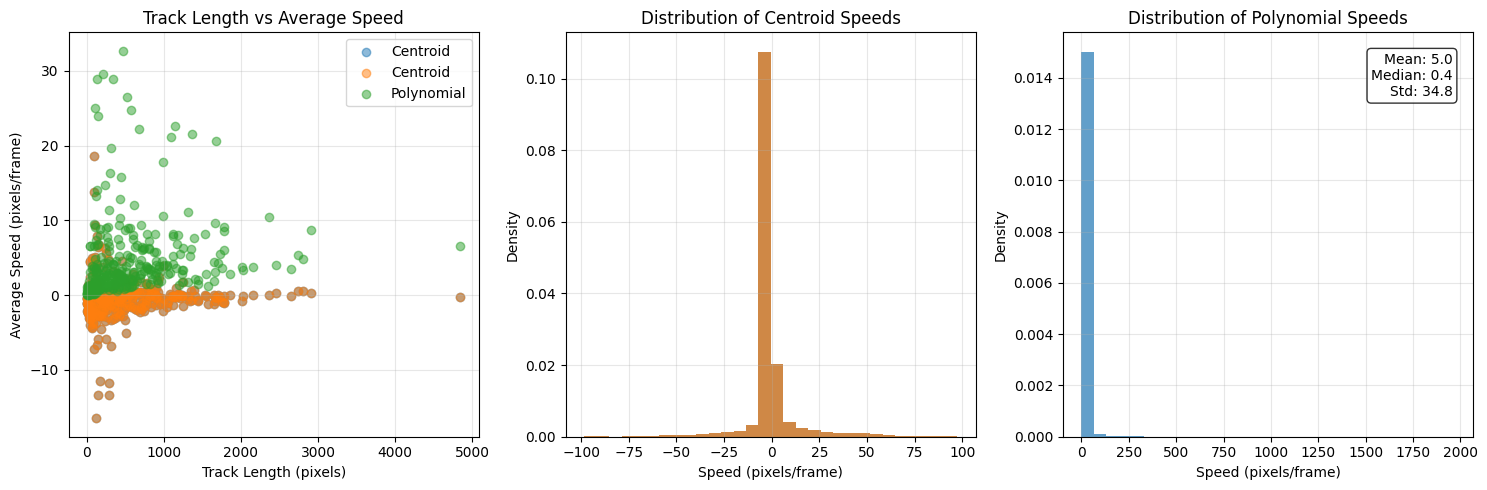


Speed Statistics:

Centroid Speeds:

Polynomial Speeds:
Total measurements: 14503
Mean: 5.02 pixels/frame
Median: 0.43 pixels/frame
Std: 34.84 pixels/frame
Range: [0.00, 1969.48] pixels/frame


In [164]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_speeds(track_info):
    """
    Create visualizations of speed distributions and length vs speed relationships
    """
    # Collect data
    lengths = []
    avg_poly_speeds = []
    avg_centroid_x = []
    avg_centroid_y = []
    all_centroid_x = []
    all_centroid_y = []
    all_poly_speeds = []
    
    for track_id, info in track_info.items():
        # Calculate track length
        centroids = np.array(info['centroids'])
        diffs = np.diff(centroids, axis=0)
        length = np.sum(np.sqrt(np.sum(diffs**2, axis=1)))
        lengths.append(length)
        
        # Get speeds
        centroid_x = [s['dx'] for s in info['centroid_speeds']]
        centroid_y = [s['dx'] for s in info['centroid_speeds']]
        poly_speeds = [s['speed'] for s in info['normal_speeds']]
        
        avg_centroid_x.append(np.mean(centroid_x))
        avg_centroid_y.append(np.mean(centroid_y))
        avg_poly_speeds.append(np.mean(poly_speeds))
        all_centroid_x.extend(centroid_y)
        all_centroid_y.extend(centroid_y)
        all_poly_speeds.extend(poly_speeds)
    
    # Create figure with three subplots
    fig = plt.figure(figsize=(15, 5))
    
    # 1. Length vs Average Speed Scatter Plot
    ax1 = fig.add_subplot(131)
    ax1.scatter(lengths, avg_centroid_x, alpha=0.5, label='Centroid')
    ax1.scatter(lengths, avg_centroid_y, alpha=0.5, label='Centroid')
    ax1.scatter(lengths, avg_poly_speeds, alpha=0.5, label='Polynomial')

    ax1.set_xlabel('Track Length (pixels)')
    ax1.set_ylabel('Average Speed (pixels/frame)')
    ax1.set_title('Track Length vs Average Speed')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # 2. Centroid Speed Histogram
    ax2 = fig.add_subplot(132)
    ax2.hist(all_centroid_x, bins=30, alpha=0.7, density=True)
    ax2.hist(all_centroid_y, bins=30, alpha=0.7, density=True)
    ax2.set_yscale('log')
    ax2.set_xlabel('Speed (pixels/frame)')
    ax2.set_ylabel('Density')
    ax2.set_title('Distribution of Centroid Speeds')
    ax2.grid(True, alpha=0.3)
    
    # Add statistics as text
    # stats = f'Mean: {np.mean(all_centroid_speeds):.1f}\n'
    # stats += f'Median: {np.median(all_centroid_speeds):.1f}\n'
    # stats += f'Std: {np.std(all_centroid_speeds):.1f}'
    # ax2.text(0.95, 0.95, stats,
    #          transform=ax2.transAxes,
    #          verticalalignment='top',
    #          horizontalalignment='right',
    #          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # 3. Polynomial Speed Histogram
    ax3 = fig.add_subplot(133)
    ax3.hist(all_poly_speeds, bins=30, alpha=0.7, density=True)
    ax3.set_yscale('log')
    ax3.set_xlabel('Speed (pixels/frame)')
    ax3.set_ylabel('Density')
    ax3.set_title('Distribution of Polynomial Speeds')
    ax3.grid(True, alpha=0.3)
    
    # Add statistics as text
    stats = f'Mean: {np.mean(all_poly_speeds):.1f}\n'
    stats += f'Median: {np.median(all_poly_speeds):.1f}\n'
    stats += f'Std: {np.std(all_poly_speeds):.1f}'
    ax3.text(0.95, 0.95, stats,
             transform=ax3.transAxes,
             verticalalignment='top',
             horizontalalignment='right',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.tight_layout()
    plt.show()
    
    # Print additional statistics
    print("\nSpeed Statistics:")
    print("\nCentroid Speeds:")
    # print(f"Total measurements: {len(all_centroid_speeds)}")
    # print(f"Mean: {np.mean(all_centroid_speeds):.2f} pixels/frame")
    # print(f"Median: {np.median(all_centroid_speeds):.2f} pixels/frame")
    # print(f"Std: {np.std(all_centroid_speeds):.2f} pixels/frame")
    # print(f"Range: [{np.min(all_centroid_speeds):.2f}, {np.max(all_centroid_speeds):.2f}] pixels/frame")
    
    print("\nPolynomial Speeds:")
    print(f"Total measurements: {len(all_poly_speeds)}")
    print(f"Mean: {np.mean(all_poly_speeds):.2f} pixels/frame")
    print(f"Median: {np.median(all_poly_speeds):.2f} pixels/frame")
    print(f"Std: {np.std(all_poly_speeds):.2f} pixels/frame")
    print(f"Range: [{np.min(all_poly_speeds):.2f}, {np.max(all_poly_speeds):.2f}] pixels/frame")

# Usage:
track_info = tracker.get_track_info()
analyze_speeds(track_info)

In [127]:
track_info = tracker.get_track_info()

In [128]:
track_info[0].keys()

dict_keys(['frames', 'contacts', 'centroids'])